# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from math import ceil

In [2]:
sessions_history=pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
table_users_count = sessions_history.groupby('user_id').agg({'session_id': 'nunique'}).reset_index()

max_sessions_user = table_users_count.sort_values('session_id', ascending=False).iloc[0]['user_id']

sessions_history[sessions_history['user_id'] == max_sessions_user].sort_values('session_number')

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

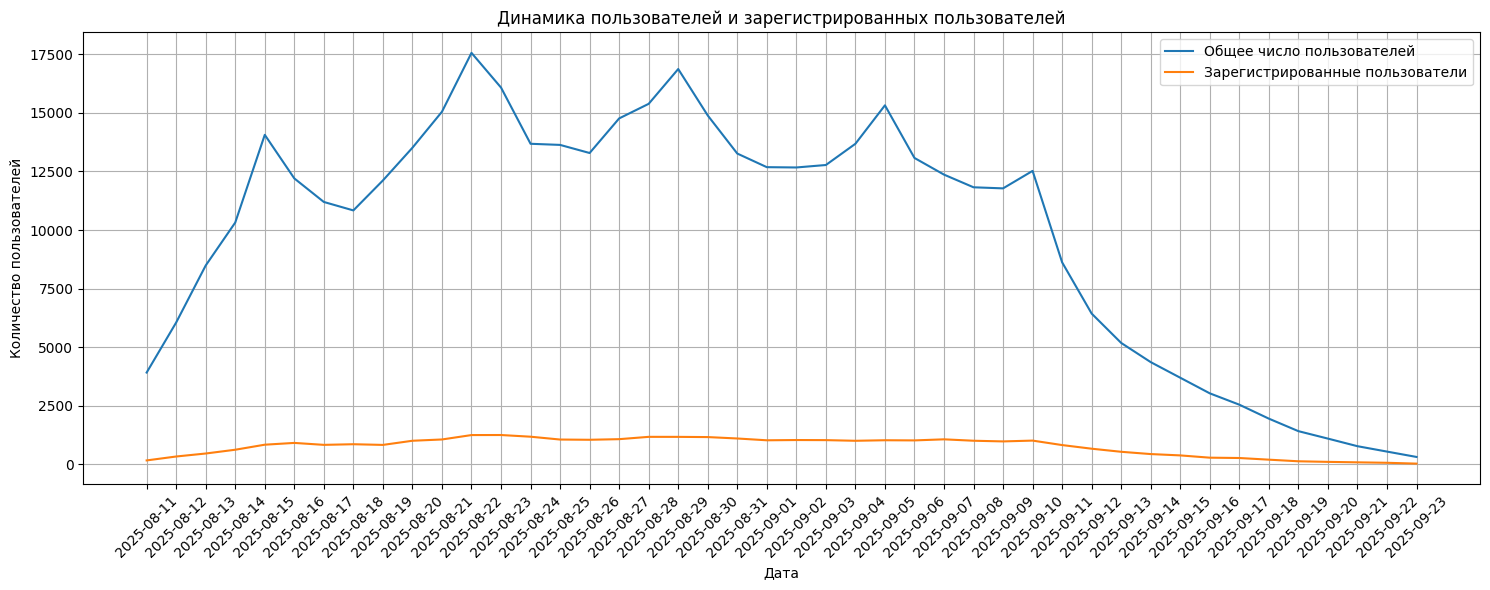

In [4]:
daily_stats = sessions_history.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'}).reset_index()
daily_stats['shape_reg'] = daily_stats['registration_flag'] / daily_stats['user_id']*100

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_stats, x='session_date', y='user_id', label='Общее число пользователей')
sns.lineplot(data=daily_stats, x='session_date', y='registration_flag', label='Зарегистрированные пользователи')
plt.title('Динамика пользователей и зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

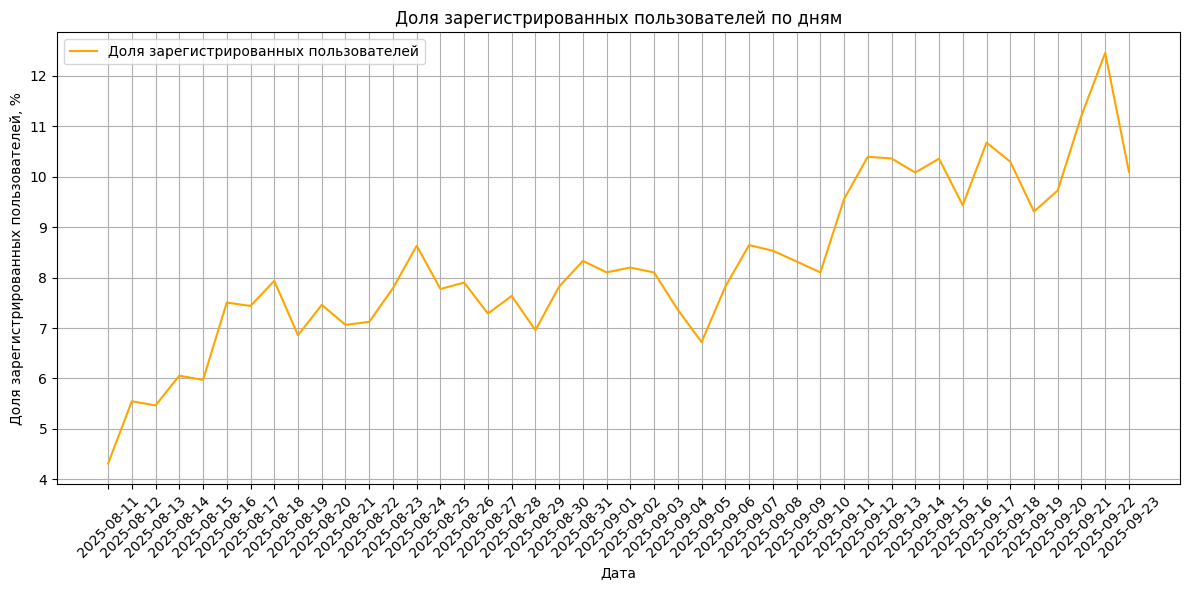

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_stats, x='session_date', y='shape_reg', label='Доля зарегистрированных пользователей', color='orange')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

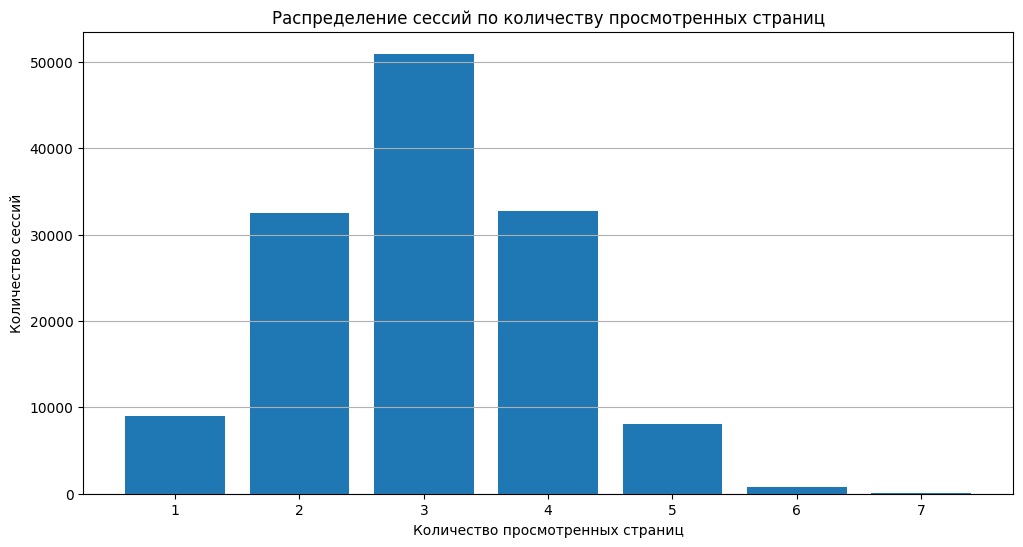

In [6]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]
pages_count = first_sessions.groupby('page_counter')['session_id'].count().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(pages_count['page_counter'], pages_count['session_id'])
plt.title('Распределение сессий по количеству просмотренных страниц')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(axis='y')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

/var/folders/d_/vkgbs03j1v55mtc06591kxy00000gn/T/ipykernel_47693/1262277303.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=first_sessions, x='session_date', y='good_session', label='Доля хороших сессий', color='green', ci=None)


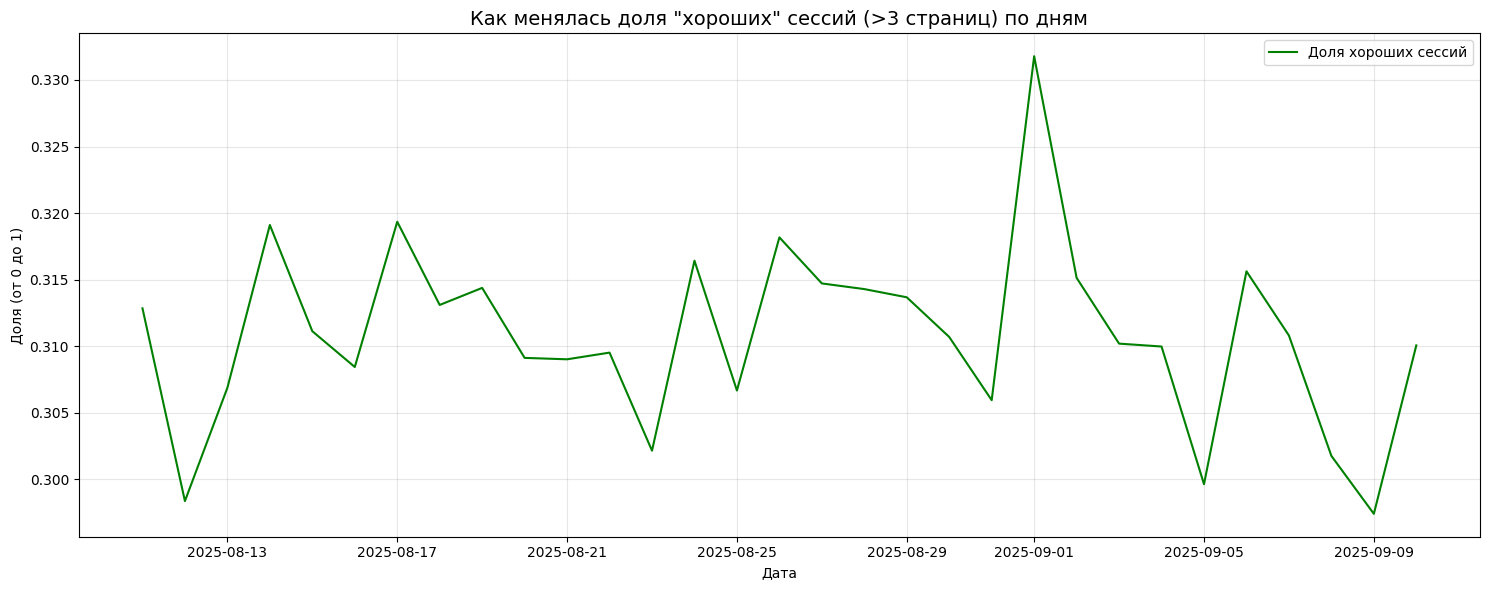

In [7]:
sessions_history['good_session'] = pd.cut(
    sessions_history['page_counter'], 
    bins=[0, 3, float('inf')], 
    labels=[0, 1]
).astype(int)
first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()
first_sessions['session_date'] = pd.to_datetime(first_sessions['session_date'])
first_sessions = first_sessions.sort_values('session_date')

plt.figure(figsize=(15, 6))
sns.lineplot(data=first_sessions, x='session_date', y='good_session', label='Доля хороших сессий', color='green', ci=None)
plt.title('Как менялась доля "хороших" сессий (>3 страниц) по дням', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Доля (от 0 до 1)') # 0.5 на графике будет значить 50% хороших сессий
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [8]:
alpha = 0.05
power = 0.8
p = 0.3          
mde_percent = 0.03 # 
p_new = p * (1 + mde_percent) 

eff_size = proportion_effectsize(p, p_new)
power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size = eff_size, 
    power = power,
    alpha = alpha,
    ratio = 1,
    alternative = 'two-sided'
)

print(f"Ожидаемая конверсия в группе B: {p_new:.4f}")
print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Ожидаемая конверсия в группе B: 0.3090
Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [9]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [10]:
sessions_test_part=pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

Группа A: 1477 пользователей
Группа B: 1466 пользователей
Процентное различие между группами: 0.74%


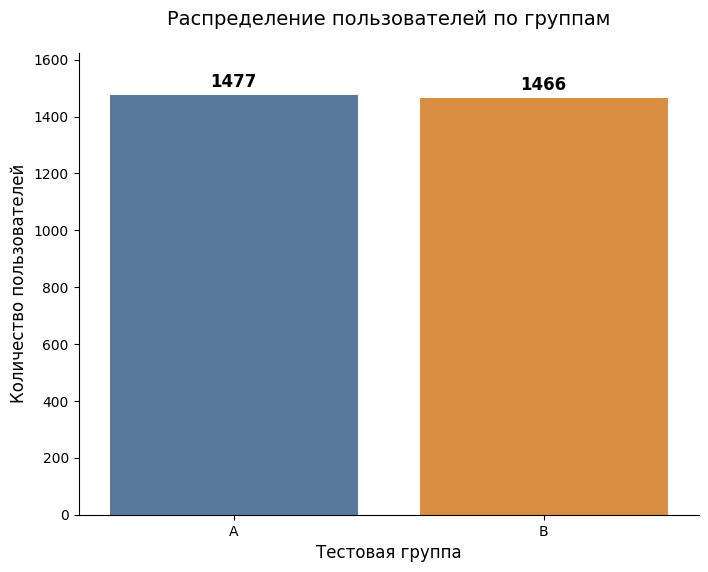

In [11]:
test_group_users = sessions_test_part.groupby('test_group')['user_id'].nunique()
group_a = test_group_users['A']
group_b = test_group_users['B']
percent_diff = (group_a - group_b) / group_a * 100
print(f"Группа A: {group_a} пользователей")
print(f"Группа B: {group_b} пользователей")
print(f"Процентное различие между группами: {percent_diff:.2f}%")

my_colors = ["#4E79A7", "#F28E2B"] 

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=test_group_users.index, 
    y=test_group_users.values, 
    palette=my_colors,
    hue=test_group_users.index, 
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Распределение пользователей по группам', fontsize=14, pad=20)
plt.xlabel('Тестовая группа', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

sns.despine()

plt.ylim(0, max(test_group_users.values) * 1.1)
plt.show()


#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [12]:
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

common_users = users_a.intersection(users_b)

print(f"Количество пользователей в обеих группах: {len(common_users)}")

Количество пользователей в обеих группах: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


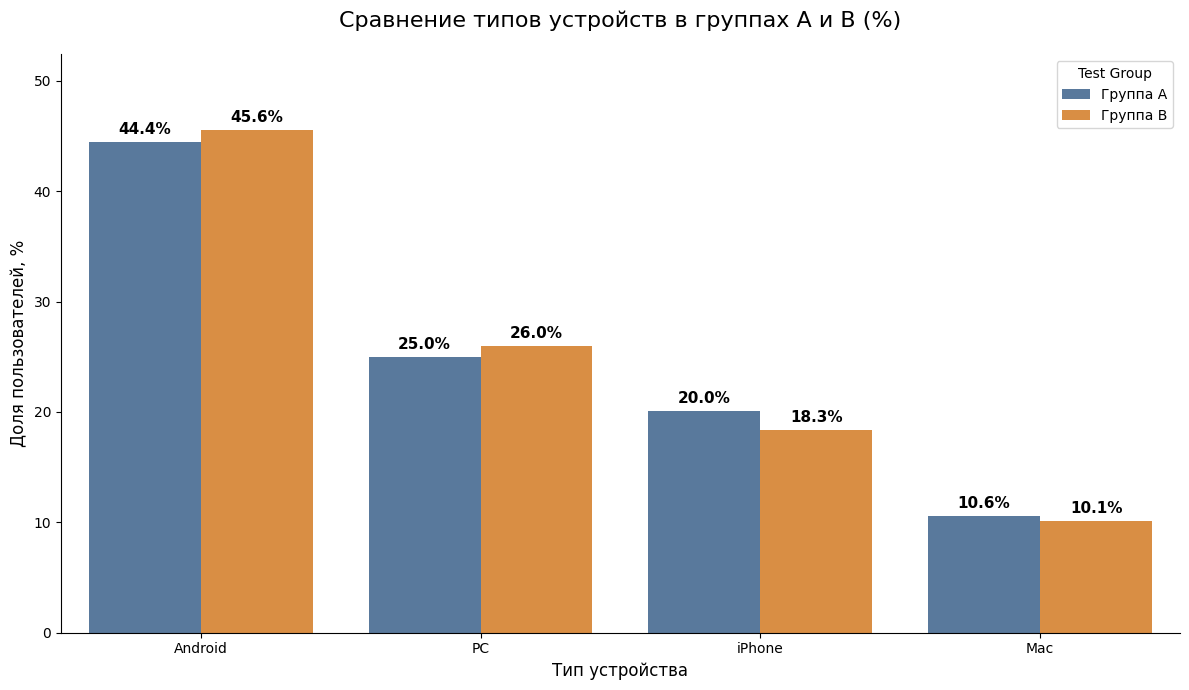

In [13]:
unique_devices_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].drop_duplicates(subset='user_id')
unique_devices_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].drop_duplicates(subset='user_id')

device_a = unique_devices_a['device'].value_counts(normalize=True) * 100
device_b = unique_devices_b['device'].value_counts(normalize=True) * 100

device_compare = pd.DataFrame({
    'Device': device_a.index,
    'Группа A': device_a.values,
    'Группа B': device_b.values
}).melt(id_vars='Device', var_name='Test Group', value_name='Percentage')

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=device_compare, 
    x='Device', 
    y='Percentage', 
    hue='Test Group', 
    palette=["#4E79A7", "#F28E2B"]
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

plt.title('Сравнение типов устройств в группах A и B (%)', fontsize=16, pad=20)
plt.ylabel('Доля пользователей, %', fontsize=12)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylim(0, max(device_compare['Percentage']) * 1.15)
sns.despine() # Убираем лишние рамки

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

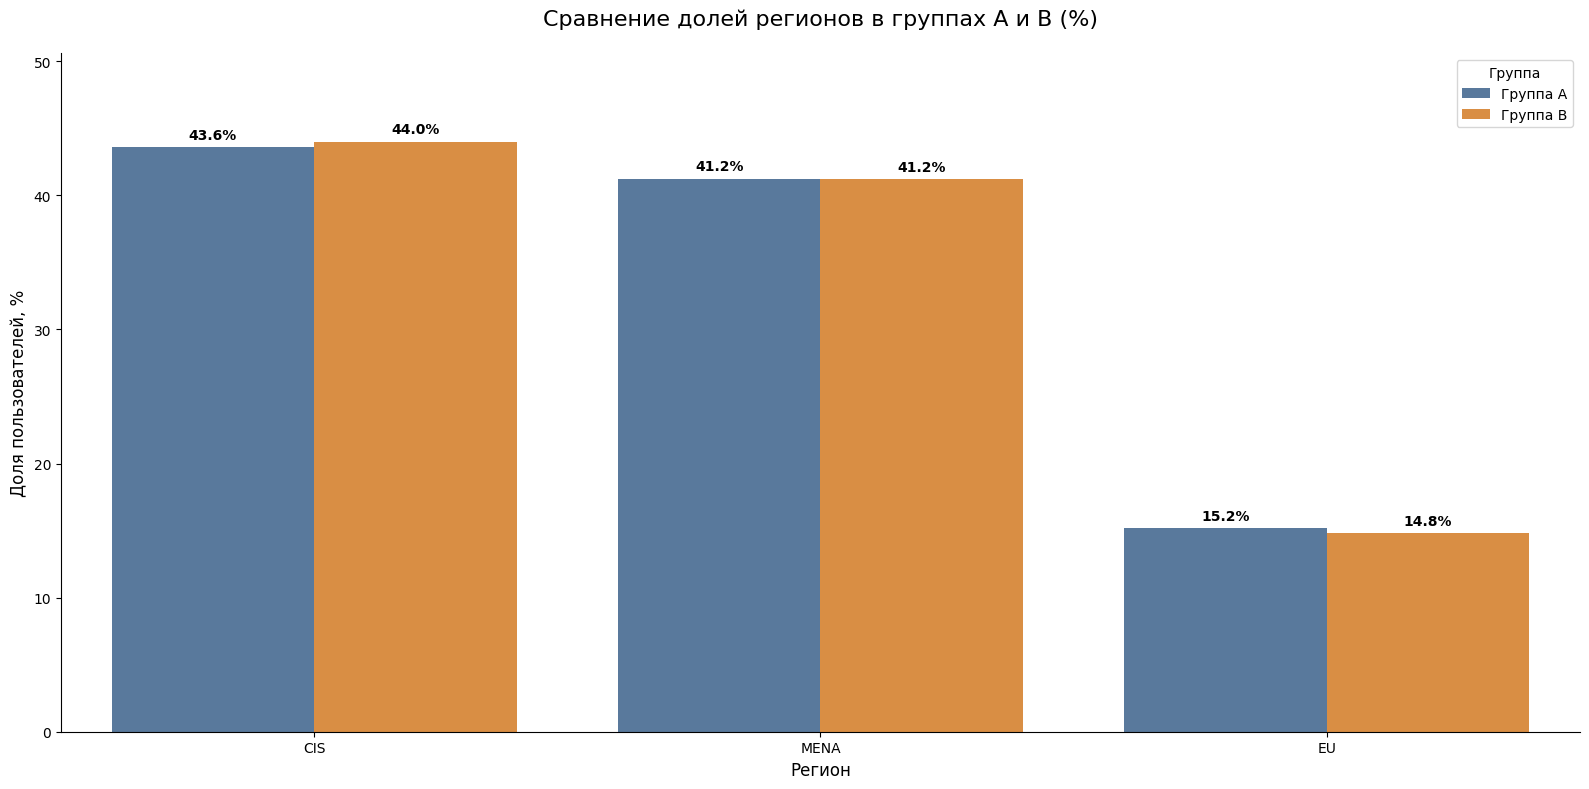

In [14]:
unique_users_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].drop_duplicates(subset='user_id')
unique_users_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].drop_duplicates(subset='user_id')

region_a = unique_users_a['region'].value_counts(normalize=True) * 100
region_b = unique_users_b['region'].value_counts(normalize=True) * 100

region_compare = pd.DataFrame({
    'Region': region_a.index,
    'Группа A': region_a.values,
    'Группа B': region_b.values
}).melt(id_vars='Region', var_name='Test Group', value_name='Percentage')


plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=region_compare, 
    x='Region', 
    y='Percentage', 
    hue='Test Group', 
    palette=["#4E79A7", "#F28E2B"]
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold', rotation=0)

plt.title('Сравнение долей регионов в группах A и B (%)', fontsize=16, pad=20)
plt.ylabel('Доля пользователей, %', fontsize=12)
plt.xlabel('Регион', fontsize=12)
plt.legend(title='Группа')
plt.ylim(0, max(region_compare['Percentage']) * 1.15) 
sns.despine() 

plt.tight_layout()
plt.show()


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Вывод:**    
На основе проведённого анализа A/B-теста можно сделать следующие выводы:   
-В тесте наблюдается небольшая разница в количестве пользователей между группами A и B. Это может быть связано с случайными колебаниями, но стоит продолжать мониторинг, чтобы убедиться, что эта разница не увеличивается.   
-В тесте не обнаружено пересечения пользователей между группами A и B, что говорит о том, что выборки являются независимыми.   
-Распределение пользователей по типам устройств в группах A и B совпадает, что говорит о том, что пользователи в обеих группах используют схожие устройства.   
-Распределение пользователей по регионам в группах A и B также совпадает, что говорит о том, что пользователи в обеих группах представляют схожие регионы.   
-В целом, на данном этапе тест проходит корректно, и нет признаков нарушений. Однако важно продолжать мониторинг, чтобы убедиться, что эти тенденции сохраняются на протяжении всего теста.   

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [15]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [16]:
sessions_test['good_session'] = pd.cut(
    sessions_test['page_counter'], 
    bins=[0, 3, float('inf')], 
    labels=[0, 1]
).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Формулировка гипотез**   
*Нулевая гипотеза*: Новый алгоритм рекомендаций не влияет на вовлеченность новых пользователей. Доля «хороших» первых сессий в группе B равна доле в группе A.   
*Альтернативная гипотеза*: Новый алгоритм рекомендаций повышает вовлеченность новых пользователей. Доля «хороших» первых сессий в группе B статистически значимо выше, чем в группе A.

**Целевая метрика**: Доля «хороших сессий» (сессий, в которых пользователь просмотрел 4 и более страниц) *среди первых сессий пользователей.*

**Прокси-метрика**: Среднее количество просмотренных страниц за сессию. Если новый алгоритм рекомендаций действительно улучшает качество контента, то пользователи должны просматривать больше страниц за одну сессию.

**Барьерная метрика**: Скорость загрузки страниц. Если новый алгоритм рекомендаций требует больше ресурсов и замедляет работу приложения, это может негативно сказаться на пользовательском опыте, даже если контент становится более интересным. Поэтому важно отслеживать скорость загрузки страниц в качестве барьерной метрики.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [17]:
group_users_a = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]
group_users_b = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]

share_good_session_a = group_users_a['good_session'].value_counts(normalize=True)
print (f"Доля хороших сессий в группе A: {share_good_session_a[1]:.2%}")
share_good_session_b = group_users_b['good_session'].value_counts(normalize=True)
print (f"Доля хороших сессий в группе B: {share_good_session_b[1]:.2%}")
print(f"Разница в доле хороших сессий между группами: {(share_good_session_b[1] - share_good_session_a[1]):.2%}")

Доля хороших сессий в группе A: 31.57%
Доля хороших сессий в группе B: 31.47%
Разница в доле хороших сессий между группами: -0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [18]:
m_a=sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]['good_session'].sum()
m_b=sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]['good_session'].sum()

n_a=sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)].shape[0]
n_b=sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)].shape[0]

alpha=0.05 

p_a, p_b = m_a/n_a, m_b/n_b

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется.')

# Проводим Z-еуст для сравнения пропорций
stat, pvalue = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller')

if pvalue>alpha:
    print(f"p-value={round(pvalue, 4)}. p-value>alpha.")
    print("Нет оснований отвергнуть нулевую гипотезу. ")
else:
    print(f"p-value={round(pvalue, 4)}. p-value<alpha.")
    print("Нулевая гипотеза не находит подтверждения.")

Предпосылка о достаточном количестве данных выполняется.
p-value=0.5784. p-value>alpha.
Нет оснований отвергнуть нулевую гипотезу. 


#### 4.5. Вывод по результатам A/B-эксперимента

В ходе проекта мы тестировали новый алгоритм рекомендаций. Основной гипотезой было предположение, что персональные подборки сделают контент интереснее, что увеличит вовлеченность.

- **Целевая метрика:** Доля «хороших сессий» (просмотр 4 и более страниц) среди первых сессий пользователей. Фокус на **новых пользователях** позволил исключить влияние лояльной аудитории и оценить «первое касание» с новым алгоритмом.
- **Уровень значимости:** 0.05.
- **Статистический метод:** Z-тест для пропорций.

**Результаты анализа данных**. 
Перед проведением теста была выполнена проверка качества данных:
- **Сплитование:** Группы А и В сбалансированы по количеству пользователей (различие менее 1%), типам устройств и географии (регионам).
- **Чистота выборок:** Пересечений пользователей между группами не обнаружено, группы независимы.

**Результаты тестирования гипотез**
Анализ ключевой метрики на отфильтрованных данных (только первые сессии) показал:
* Конверсия в «хорошую сессию» в группе А (контроль): 31.57%.
* Конверсия в «хорошую сессию» в группе B (тест): 31.47%.
* Абсолютная разница составила всего -0.11%.
* P-value = 0.5784, что значительно выше установленного порога в 0.05.

**Интерпретация и бизнес-решение**
Полученное значение говорит о том, что у нас *нет оснований отвергнуть нулевую гипотезу.* Наблюдаемая разница в -0.11% не является статистически значимой и вызвана случайными колебаниями данных.
**Вывод:** Новый алгоритм рекомендаций не подтвердил свою эффективность на новых пользователях. Несмотря на то, что при анализе всех сессий наблюдался ложный прирост, детальный разбор первых сессий показал отсутствие реального улучшения вовлеченности.

**Рекомендация:**
1. Не внедрять текущую версию алгоритма на всех пользователей.
2. Направить алгоритм на доработку команде разработки.
3. Провести дополнительное исследование (UX-тесты или опросы), чтобы понять, почему рекомендации не «цепляют» новичков в первую сессию.